# **P**anatopic **A**dversarial **N**uclei **C**lassification **a**nd **K**nowledge-**E**nhanced **S**egmentation using Pathopix-GANs

Dataset Structure
The dataset is organized into three folds: fold1, fold2, and fold3, consistent with the original dataset structure. Each fold contains data in a tabular format with the following four columns:

image: The RGB tile of the sample.
instances: A list of nuclei instances. Each instance represents exactly one nucleus and is in binary format (1 - nucleus, 0 - background)
categories: An integer class label for each nucleus, corresponding to one of the following categories:

1. Neoplastic
2. Inflammatory
3. Connective
4. Dead
5. Epithelial

tissue: The integer tissue type from which the sample originates, belonging to one of these categories:

1. Adrenal Gland
2. Bile Duct
3. Bladder
4. Breast
5. Cervix
6. Colon
7. Esophagus
8. Head & Neck
9. Kidney
10. Liver
11. Lung
12. Ovarian
13. Pancreatic
14. Prostate
15. Skin
16. Stomach
17. Testis
18. Thyroid
19. Uterus




### **Libraries**

In [131]:
import pandas as pd
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math
import warnings
import ast
from collections import Counter
import seaborn as sns
import shutil
import glob
from tqdm import tqdm
import torch
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim

warnings.filterwarnings('ignore')

### **Sample Display**

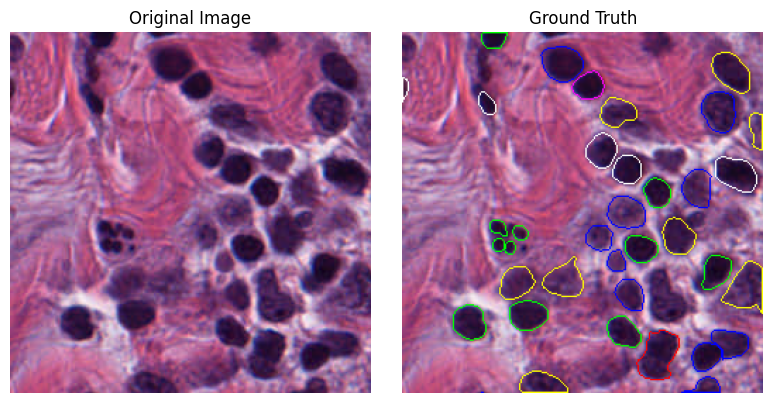

In [109]:
image_path = "/kaggle/input/pannuke/dataset/fold_3/sample_1008/image.png"
mask_dir = "/kaggle/input/pannuke/dataset/fold_3/sample_1008/masks"

category_colors = {
    "0": (255, 0, 0),    # Neoplastic - Red
    "1": (0, 255, 0),    # Inflammatory - Green
    "2": (0, 0, 255),    # Connective - Blue
    "3": (255, 255, 0),  # Dead - Yellow
    "4": (255, 0, 255)   # Epithelial - Magenta
}

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
overlay = image.copy()

mask_files = sorted(os.listdir(mask_dir))

for mask_file in mask_files:
    mask_path = os.path.join(mask_dir, mask_file)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    
    category = mask_file.split('/')[-1][7]
    color = category_colors.get(category, (255, 255, 255))
    
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(overlay, contours, -1, color, thickness=1)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(image)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(overlay)
axes[1].set_title("Ground Truth")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### **Initial Loading and Simple Preprocessing**

In [119]:
meta_data = pd.read_csv('/kaggle/input/pannuke/dataset/metadata.csv')
meta_data['category'] = meta_data['category'].str.replace(" ", ",").apply(ast.literal_eval)
meta_data = meta_data.dropna(subset=['tissue'])

meta_data['fold'] = meta_data['file_path'].str[5]
meta_data['file_path'] = meta_data['file_path'].str[:-10]
meta_data.sample(5)

,file_path,category,tissue,fold
143,fold_1/sample_143,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",3,1
7550,fold_3/sample_2371,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, ...",13,3
5047,fold_2/sample_2391,"[2, 2, 2, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, ...",17,2
6378,fold_3/sample_1199,"[2, 2, 2, 2, 2, 2, 4, 4, 4, 4, 4, 4, 4, 4, 4, ...",0,3
6393,fold_3/sample_1214,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",0,3


### **Data Distribution across Cells/Tissue**

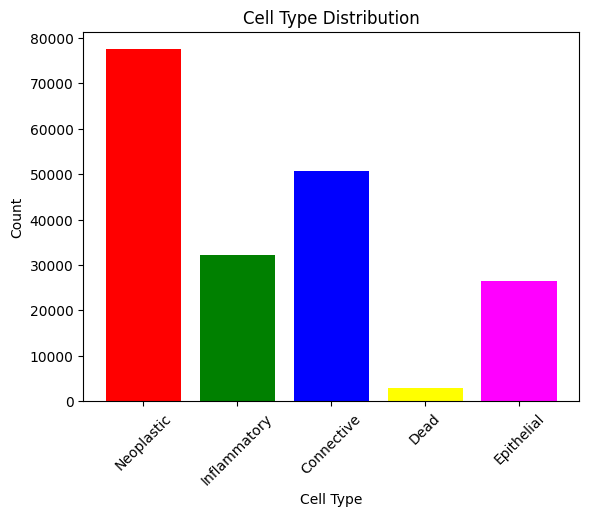

In [110]:
all_categories = [item for sublist in meta_data['category'] for item in sublist]
category_counts = Counter(all_categories)

category_names = ["Neoplastic", "Inflammatory", "Connective", "Dead", "Epithelial"]

plt.bar(category_names, [category_counts[i] for i in range(5)], 
        color=['red', 'green', 'blue', 'yellow', 'magenta'])

plt.xlabel("Cell Type")
plt.ylabel("Count")
plt.title("Cell Type Distribution")
plt.xticks(rotation=45)
plt.show()

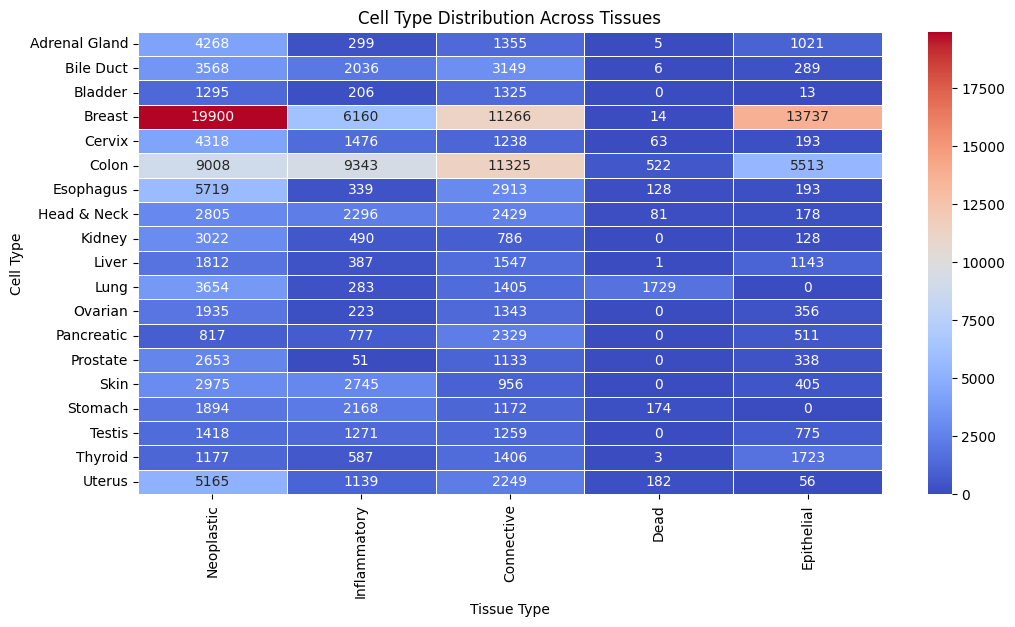

In [93]:
meta_data['tissue_labels'] = meta_data['tissue'].astype(int).map(tissue_mapping)

heatmap_data = pd.DataFrame(0, index=category_names, columns=tissue_mapping.values())

for _, row in meta_data.iterrows():
    tissue = row['tissue_labels']
    category_counts = Counter(row['category'])
    
    for cat_idx, cat_name in enumerate(category_names):
        heatmap_data.loc[cat_name, tissue] += category_counts.get(cat_idx, 0)

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data.T, cmap="coolwarm", annot=True, fmt="d", linewidths=0.5)

plt.xlabel("Tissue Type")
plt.ylabel("Cell Type")
plt.title("Cell Type Distribution Across Tissues")
plt.xticks(rotation=90)
plt.show()

## Pathopix-GANs Pipeline

### Transfer Data to PWD

## FAULTY CODE **PLEASE RESOLVE**

In [122]:
dataset_path = "/kaggle/input/pannuke/dataset"
output_path = "/kaggle/working/dead_cells"
os.makedirs(output_path, exist_ok=True)
os.makedirs(os.path.join(output_path, "images"), exist_ok=True)
os.makedirs(os.path.join(output_path, "masks"), exist_ok=True)

for fold in ["fold_1", "fold_2"]:
    fold_path = os.path.join(dataset_path, fold)
    samples = os.listdir(fold_path)

    for sample in tqdm(samples, desc=f"Processing {fold}"):
        sample_path = os.path.join(fold_path, sample)
        mask_path = os.path.join(sample_path, "masks")
        image_path = os.path.join(sample_path, "image.png")

        dead_cell_masks = glob.glob(os.path.join(mask_path, "mask_3_*.png"))

        if dead_cell_masks:
            shutil.copy(image_path, os.path.join(output_path, "images", f"{sample}.png"))
            for mask_file in dead_cell_masks:
                shutil.copy(mask_file, os.path.join(output_path, "masks", os.path.basename(mask_file)))

print("Dead Cell images & masks extracted.")

Processing fold_2: 100%|██████████| 2523/2523 [00:23<00:00, 107.87it/s]

Dead Cell images & masks extracted.


### Data Loader

In [ ]:
class DeadCellDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_paths = sorted(glob.glob(os.path.join(image_dir, "*.png")))
        self.mask_paths = sorted(glob.glob(os.path.join(mask_dir, "*.png")))
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        mask = Image.open(self.mask_paths[idx]).convert("L")

        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)

        return image, mask

transform = transforms.Compose([
    transforms.Resize((256, 256)),  
    transforms.ToTensor(),          
    transforms.Normalize([0.5], [0.5]) 
])

image_dir = "/kaggle/working/dead_cells/images"
mask_dir = "/kaggle/working/dead_cells/masks"

dataset = DeadCellDataset(image_dir, mask_dir, transform=transform)
train_loader = DataLoader(dataset, batch_size=8, shuffle=True, num_workers=2)

print(f"DataLoader Ready with {len(dataset)} samples")

DataLoader Ready with 135 samples


### Spatially-Adaptive Normalization

In [133]:
class SPADE(nn.Module):
    def __init__(self, norm_nc, label_nc):
        super().__init__()
        self.param_free_norm = nn.BatchNorm2d(norm_nc, affine=False)
        self.mlp_shared = nn.Sequential(
            nn.Conv2d(label_nc, 128, kernel_size=3, padding=1),
            nn.ReLU()
        )
        self.mlp_gamma = nn.Conv2d(128, norm_nc, kernel_size=3, padding=1)
        self.mlp_beta = nn.Conv2d(128, norm_nc, kernel_size=3, padding=1)

    def forward(self, x, seg_map):
        normalized = self.param_free_norm(x)
        seg_map = F.interpolate(seg_map, size=x.size()[2:], mode='nearest')
        actv = self.mlp_shared(seg_map)
        gamma = self.mlp_gamma(actv)
        beta = self.mlp_beta(actv)
        return normalized * (1 + gamma) + beta

class SPADEResBlk(nn.Module):
    def __init__(self, fin, fout, label_nc):
        super().__init__()
        self.learned_shortcut = (fin != fout)
        fmiddle = min(fin, fout)

        self.conv_0 = nn.Conv2d(fin, fmiddle, kernel_size=3, padding=1)
        self.conv_1 = nn.Conv2d(fmiddle, fout, kernel_size=3, padding=1)

        self.norm_0 = SPADE(fin, label_nc)
        self.norm_1 = SPADE(fmiddle, label_nc)

        if self.learned_shortcut:
            self.norm_s = SPADE(fin, label_nc)
            self.conv_s = nn.Conv2d(fin, fout, kernel_size=1, bias=False)

    def forward(self, x, seg):
        x_s = self.shortcut(x, seg)
        dx = self.conv_0(F.gelu(self.norm_0(x, seg)))
        dx = self.conv_1(F.gelu(self.norm_1(dx, seg)))
        return x_s + dx

    def shortcut(self, x, seg):
        return self.conv_s(self.norm_s(x, seg)) if self.learned_shortcut else x

### SPADE Generator

In [134]:
class SPADEGenerator(nn.Module):
    def __init__(self, z_dim=256, label_nc=1):
        super().__init__()
        self.fc = nn.Linear(z_dim, 4 * 4 * 1024)
        self.head = SPADEResBlk(1024, 1024, label_nc)
        
        self.up_blocks = nn.ModuleList([
            SPADEResBlk(1024, 512, label_nc),
            SPADEResBlk(512, 256, label_nc),
            SPADEResBlk(256, 128, label_nc),
            SPADEResBlk(128, 64, label_nc)
        ])
        
        self.final_conv = nn.Conv2d(64, 3, kernel_size=3, padding=1)

    def forward(self, z, seg):
        x = self.fc(z).view(-1, 1024, 4, 4)
        x = self.head(x, seg)

        for up_block in self.up_blocks:
            x = F.interpolate(x, scale_factor=2, mode="bilinear")
            x = up_block(x, seg)

        return torch.tanh(self.final_conv(x))

### Patch GAN and Discriminator

In [135]:
class PatchGANDiscriminator(nn.Module):
    def __init__(self, input_nc=3):
        super().__init__()
        channels = [64, 128, 256, 512]

        self.model = nn.Sequential(
            nn.Conv2d(input_nc + 1, channels[0], kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            
            nn.Conv2d(channels[0], channels[1], kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(channels[1]),
            nn.LeakyReLU(0.2),
            
            nn.Conv2d(channels[1], channels[2], kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(channels[2]),
            nn.LeakyReLU(0.2),
            
            nn.Conv2d(channels[2], channels[3], kernel_size=4, stride=1, padding=1),
            nn.BatchNorm2d(channels[3]),
            nn.LeakyReLU(0.2),

            nn.Conv2d(channels[3], 1, kernel_size=4, stride=1, padding=1)
        )

    def forward(self, img, seg):
        x = torch.cat((img, seg), dim=1)
        return self.model(x)

### Loss Functions

In [136]:
class GANLoss(nn.Module):
    def __init__(self, use_lsgan=True):
        super().__init__()
        self.criterion = nn.MSELoss() if use_lsgan else nn.BCEWithLogitsLoss()

    def forward(self, prediction, target_is_real):
        target_tensor = torch.ones_like(prediction) if target_is_real else torch.zeros_like(prediction)
        return self.criterion(prediction, target_tensor)

In [140]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

generator = SPADEGenerator().to(device)
discriminator = PatchGANDiscriminator().to(device)

g_optimizer = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
d_optimizer = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

gan_loss = GANLoss().to(device)
reconstruction_loss = nn.L1Loss().to(device)

num_epochs = 100
for epoch in range(num_epochs):
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=True)
    
    for real_img, seg_mask in loop:
        real_img, seg_mask = real_img.to(device), seg_mask.to(device)
        
        z = torch.randn(real_img.size(0), 256, device=device)
        fake_img = generator(z, seg_mask)
        
        # Train Discriminator
        d_optimizer.zero_grad()
        real_pred = discriminator(real_img, seg_mask)
        fake_pred = discriminator(fake_img.detach(), seg_mask)
        d_loss = (gan_loss(real_pred, True) + gan_loss(fake_pred, False)) / 2
        d_loss.backward()
        d_optimizer.step()
        
        # Train Generator
        g_optimizer.zero_grad()
        fake_pred = discriminator(fake_img, seg_mask)
        g_loss = gan_loss(fake_pred, True) + 10 * reconstruction_loss(fake_img, real_img)
        g_loss.backward()
        g_optimizer.step()
        
        loop.set_postfix(D_Loss=d_loss.item(), G_Loss=g_loss.item())

    print(f"Epoch {epoch+1}/{num_epochs} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

NameError: name 'train_loader' is not defined